<a href="https://colab.research.google.com/github/yaj0212/Introductory-Machine-Learning/blob/main/assignments/assn5/assn5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introductory Machine Learning: Assignment 5

**Deadline:**

Assignment 5 is due Thursday, April 23 at 11:59pm. Late work will not be accepted as per the course policies (see the Syllabus and Course policies on [Canvas](https://canvas.yale.edu).

Directly sharing answers is not okay, but discussing problems with the course staff or with other students is encouraged. Acknowledge any use of an AI system such as Gemini, ChatGPT or CoPilot.

You should start early so that you have time to get help if you're stuck. The drop-in office hours schedule can be found on [Canvas](https://canvas.yale.edu).  You can also post questions or start discussions on [Ed Discussion](https://edstem.org/us/courses/44592/discussion). The problems are broken up into steps that should help you to make steady progress.

**Submission:**

Submit your assignment as a .pdf on Gradescope. You can access Gradescope through Canvas on the left-side of the class home page. The problems in each homework assignment are numbered. Note: When submitting on Gradescope, please select the correct pages of your pdf that correspond to each problem. This will allow graders to find your complete solution to each problem.

To produce the .pdf, please do the following in order to preserve the cell structure of the notebook:  
1.  Go to "File" at the top-left of your Jupyter Notebook
2.  Under "Download as", select "HTML (.html)"
3.  After the .html has downloaded, open it and then select "File" and "Print" (note you will not actually be printing)
4.  From the print window, select the option to save as a .pdf

**Topics**
1. Topic models (30 points)
2. Neural networks (30 points)
3. Reinforcement learning (25 points)

This assignment contains three required problems. Problem 1 has you building topic models to improve pricing of houses on Zillow. Problem 2 gives you experience with neural networks in pytorch. Problem 3 is a reinforcement learning task similar to the Taxi problem, but with a random environment.

The assignment looks longer than it really is. We step you through most of the code that you need. But it's still on the long side.


## Problem 1: Read before you buy! (30 points)

![zillow](https://raw.githubusercontent.com/YData123/sds265-sp26/main/assignments/assn5/zillow.png)

### Overview of the problem

Here we have a dataset of single family houses sold in Connecticut near the beginning of 2021, collected from [Zillow](https://www.zillow.com/homes/connecticut_rb/). You will build linear models of the price for which each house sold, based on its characteristics given in the real estate listing. Such characteristics include internal square footage, the year it was built, the bedroom count, the bathroom count, and the area of the lot.

But there is also usually a lengthy description written by the real estate agent. Is there any additional information hidden in this description that would help improve the model of the price? This is the question we focus on in this problem.

Answering such a question is difficult because the description is written in natural language with thousands of different words. Here we use topic models as a dimension reduction technique. Specifically, instead of using thousands of possible words, and how many times they show up in each house description, we reduce the words to the topic proportions $\theta_d$ for each document, obtained by posterior inference. These proportions are combined with the other quantitative variables in a linear model with the logarithm of the house price as the response variable.

*Important note:* At first glance, this problem looks really long. But this is deceiving.
After reading in the data, we have you make some plots of the log-transformed variables.
After that, you just need to run the code that leads up to training a 10-topic topic model,
and fitting a linear model using the resulting topic proportions. After this, you are asked to compare the results to those obtained with a 3-topic model. To do this, you can simply copy the code used for the 10-topic model. After that, the crux of the problem is to analyze, understand, and describe the results.

Acknowledgment: The data were scraped and the analysis was done by [Parker Holzer](https://parkerholzer.github.io/), as he began his search for a new house for his family after beginning a job as a data scientist. Thanks Parker!


In [1]:
import numpy as np
import pandas as pd
import re
from sklearn.decomposition import LatentDirichletAllocation
from scipy.sparse import csr_matrix
from collections import Counter
import statsmodels.formula.api as sm
import matplotlib.pyplot as plt
%matplotlib inline

### Read in and clean up the data


In [2]:
ct_homes = pd.read_csv('https://raw.githubusercontent.com/YData123/sds265-sp26/main/assignments/assn5/ct_zillow.csv')
ct_homes

,AREA,BED,BATH,BUILT,DESCRIPTION,LOTSIZE,PRICE
0,1629.0,2.0,2.0,1889.0,"Welcome home! Charming & well kept, this 2 bed...",0.159986,224000.0
1,1278.0,3.0,2.0,1900.0,This adorable cape has a lot to offer. You st...,0.179981,225000.0
2,1264.0,3.0,2.0,1988.0,This 1264 sqft Colonial with its 3 bedrooms an...,0.089991,224900.0
3,2054.0,3.0,3.0,1960.0,The perfect oversized ranch awaits you at 7 No...,0.569994,370000.0
4,4198.0,5.0,3.0,1972.0,Beautiful Colonial-3020 sqft. living space and...,0.939989,489999.0
...,...,...,...,...,...,...,...
1921,848.0,3.0,2.0,1948.0,This home sets at the beginning of a Cul-de-Sa...,0.189990,429900.0
1922,2400.0,4.0,4.0,2021.0,New home to be built. Amazing unobstructed wat...,0.079981,800000.0
1923,6538.0,7.0,7.0,2002.0,Can you say water views galore? Wake up to the...,0.079981,2700000.0
1924,4480.0,5.0,5.0,1890.0,NEW YEAR! NEW FUTURE! Escape NY to Connect...,0.849998,2550000.0


#### Transform the data

We add columns to `ct_homes` called `logAREA`, `logLOTSIZE`, and `logPRICE` that take the logarithms of the corresponding columns in the original data.


In [3]:
ct_homes['logAREA'] = np.log(ct_homes['AREA'])
ct_homes['logLOTSIZE'] = np.log(ct_homes['LOTSIZE'])
ct_homes['logPRICE'] = np.log(ct_homes['PRICE'])
ct_homes

,AREA,BED,BATH,BUILT,DESCRIPTION,LOTSIZE,PRICE,logAREA,logLOTSIZE,logPRICE
0,1629.0,2.0,2.0,1889.0,"Welcome home! Charming & well kept, this 2 bed...",0.159986,224000.0,7.395722,-1.832669,12.319401
1,1278.0,3.0,2.0,1900.0,This adorable cape has a lot to offer. You st...,0.179981,225000.0,7.153052,-1.714902,12.323856
2,1264.0,3.0,2.0,1988.0,This 1264 sqft Colonial with its 3 bedrooms an...,0.089991,224900.0,7.142037,-2.408049,12.323411
3,2054.0,3.0,3.0,1960.0,The perfect oversized ranch awaits you at 7 No...,0.569994,370000.0,7.627544,-0.562129,12.821258
4,4198.0,5.0,3.0,1972.0,Beautiful Colonial-3020 sqft. living space and...,0.939989,489999.0,8.342364,-0.061887,13.102159
...,...,...,...,...,...,...,...,...,...,...
1921,848.0,3.0,2.0,1948.0,This home sets at the beginning of a Cul-de-Sa...,0.189990,429900.0,6.742881,-1.660781,12.971308
1922,2400.0,4.0,4.0,2021.0,New home to be built. Amazing unobstructed wat...,0.079981,800000.0,7.783224,-2.525960,13.592367
1923,6538.0,7.0,7.0,2002.0,Can you say water views galore? Wake up to the...,0.079981,2700000.0,8.785387,-2.525960,14.808762
1924,4480.0,5.0,5.0,1890.0,NEW YEAR! NEW FUTURE! Escape NY to Connect...,0.849998,2550000.0,8.407378,-0.162521,14.751604


### Problem 1.1: Plot the data

1. Show histograms of each of the log-transformed columns.

1. Our regression models will use these transformed values. Why might it be preferable to use the logarithms rather than the original data? Explain.


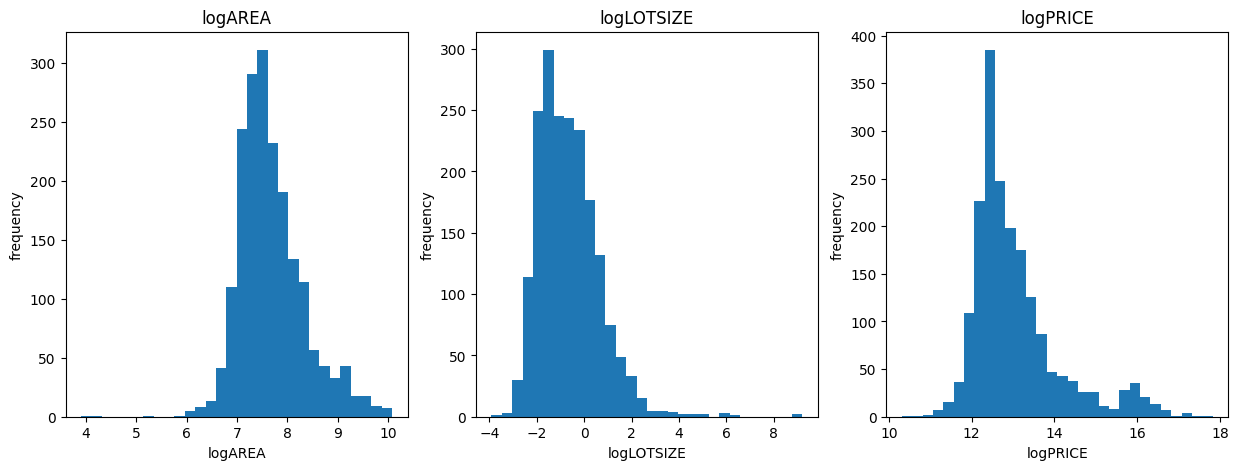

In [24]:
# your code here
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(ct_homes['logAREA'], bins=30)
axes[0].set_title('logAREA')
axes[0].set_xlabel('logAREA')
axes[0].set_ylabel('frequency')

axes[1].hist(ct_homes['logLOTSIZE'], bins=30)
axes[1].set_title('logLOTSIZE')
axes[1].set_xlabel('logLOTSIZE')
axes[1].set_ylabel('frequency')

axes[2].hist(ct_homes['logPRICE'], bins=30)
axes[2].set_title('logPRICE')
axes[2].set_xlabel('logPRICE')
axes[2].set_ylabel('frequency')

plt.show()

Taking the logarithms can make the data more suitable for regression by reducing skewness and lessening the impact of extreme values. It often helps create more linear relationships and stabilizes variability across the data. Additionally, results are easier to interpret in terms of relative or percentage changes rather than absolute differences.

Let's look at one of the descriptions as an example.


In [25]:
example = 9
ct_homes["DESCRIPTION"][example]

"One of Ridgefield's most admired homes, custom built with absolutely no expense spared. Stunning Stone and Clapboard New England Colonial with exceptional architectural details throughout, beautifully sited on 1.48 park-like acres. The heart of this home features an updated gourmet Kitchen with Dacor double ovens, Viking cook top and Sub Zero Refrigerator. Gorgeous Taj Mahal Quartz counters and island with Tumbled Limestone back splash. Stylish Living Room with propane fireplace and spacious Dining Room with large Butler's pantry also with quartz and tumbled marble. Handsome Cherry paneled Library and sun filled Family Room with fireplace and built-in cabinets and desk. The Upper level features a large Master Suite with custom marble bath and generous walk-in closet. Three Bedrooms are en suite; and two bedrooms share a lovely Jack n Jill Bathroom. Large, custom Laundry Room and over sized Bonus Room round out the second floor. Other convenient features include front and rear staircas

#### Helper functions

The following two functions will be used to clean up the text a bit and separate into tokens


In [26]:
def cleanup_description(desc):
    if type(desc) == float:
        desc = ""
    words = [re.sub(r'[^a-z]', '', w) for w in desc.lower().split(' ')]
    return ' '.join(words)

def reduce_to_vocabulary(desc, vocab):
    return ' '.join([w for w in cleanup_description(desc).split(' ') if w in vocab])


In [27]:
cleanup_description(ct_homes['DESCRIPTION'][example])

'one of ridgefields most admired homes custom built with absolutely no expense spared stunning stone and clapboard new england colonial with exceptional architectural details throughout beautifully sited on  parklike acres the heart of this home features an updated gourmet kitchen with dacor double ovens viking cook top and sub zero refrigerator gorgeous taj mahal quartz counters and island with tumbled limestone back splash stylish living room with propane fireplace and spacious dining room with large butlers pantry also with quartz and tumbled marble handsome cherry paneled library and sun filled family room with fireplace and builtin cabinets and desk the upper level features a large master suite with custom marble bath and generous walkin closet three bedrooms are en suite and two bedrooms share a lovely jack n jill bathroom large custom laundry room and over sized bonus room round out the second floor other convenient features include front and rear staircases mud room with builti


#### Next we build a vocabulary of words


In [28]:
vocab = Counter()
for dsc in ct_homes['DESCRIPTION']:
    vocab.update(cleanup_description(dsc).split(' '))


In [29]:
print("Number of unique tokens: %d" % len(vocab))

Number of unique tokens: 9738


#### Remove words that are either too common or too rare


In [31]:
vocab = Counter(token for token in vocab.elements() if vocab[token] > 5)
stop_words = [item[0] for item in vocab.most_common(50)]
vocab = Counter(token for token in vocab.elements() if token not in stop_words)
print("Number of unique tokens: %d" % len(vocab))

Number of unique tokens: 2490


#### Build a mapping between unique words and integers


In [32]:
desc = ct_homes['DESCRIPTION'][example]
print('Original description:\n---------------------')
print(desc)

print('\nCleaned up text:\n----------------')
print(cleanup_description(desc))

print('\nReduced to vocabulary:\n----------------------')
print(reduce_to_vocabulary(desc, vocab))

Original description:
---------------------
One of Ridgefield's most admired homes, custom built with absolutely no expense spared. Stunning Stone and Clapboard New England Colonial with exceptional architectural details throughout, beautifully sited on 1.48 park-like acres. The heart of this home features an updated gourmet Kitchen with Dacor double ovens, Viking cook top and Sub Zero Refrigerator. Gorgeous Taj Mahal Quartz counters and island with Tumbled Limestone back splash. Stylish Living Room with propane fireplace and spacious Dining Room with large Butler's pantry also with quartz and tumbled marble. Handsome Cherry paneled Library and sun filled Family Room with fireplace and built-in cabinets and desk. The Upper level features a large Master Suite with custom marble bath and generous walk-in closet. Three Bedrooms are en suite; and two bedrooms share a lovely Jack n Jill Bathroom. Large, custom Laundry Room and over sized Bonus Room round out the second floor. Other convenie

#### Build a mapping between unique words and integers


In [33]:
id2word = {idx: pair[0] for idx, pair in enumerate(vocab.items())}
word2id = {pair[0]: idx for idx, pair in enumerate(vocab.items())}

s = 'nyc'
print("Number of tokens mapped: %d" % len(id2word))
print("Identifier for '%s': %d" % (s,word2id[s]))
print("Word for identifier %d: %s" % (word2id[s], id2word[word2id[s]]))

Number of tokens mapped: 2490
Identifier for 'nyc': 430
Word for identifier 430: nyc


#### Map to word id format

Now, use the format required to build a language model, mapping each word to its id,


In [34]:
tokens = []
for dsc in ct_homes['DESCRIPTION']:
    clean = reduce_to_vocabulary(cleanup_description(dsc), vocab)
    toks = clean.split(' ')
    tokens.append(toks)

In [35]:
corpus = []
for toks in tokens:
    tkn_count = Counter(toks)
    corpus.append([(word2id[item[0]], item[1]) for item in tkn_count.items()])

dsc = ct_homes['DESCRIPTION'][example]
clean = reduce_to_vocabulary(cleanup_description(dsc), vocab)
toks = clean.split(' ')
print("Abstract, tokenized:\n", toks, "\n")
print("Abstract, in corpus format:\n", corpus[10])

# Build document-term matrix for sklearn
num_docs = len(corpus)
num_terms = len(id2word)
rows, cols, vals = [], [], []
for doc_idx, doc in enumerate(corpus):
    for term_id, count in doc:
        rows.append(doc_idx)
        cols.append(term_id)
        vals.append(count)
dtm = csr_matrix((vals, (rows, cols)), shape=(num_docs, num_terms))


Abstract, tokenized:
 ['most', 'homes', 'built', 'absolutely', 'no', 'expense', 'spared', 'stunning', 'stone', 'clapboard', 'england', 'exceptional', 'architectural', 'details', 'beautifully', 'sited', 'parklike', 'acres', 'heart', 'gourmet', 'dacor', 'double', 'ovens', 'viking', 'cook', 'top', 'sub', 'refrigerator', 'gorgeous', 'quartz', 'counters', 'island', 'limestone', 'splash', 'stylish', 'propane', 'butlers', 'pantry', 'quartz', 'marble', 'handsome', 'cherry', 'paneled', 'library', 'sun', 'filled', 'builtin', 'cabinets', 'desk', 'upper', 'marble', 'generous', 'walkin', 'three', 'en', 'share', 'lovely', 'jack', 'n', 'jill', 'over', 'sized', 'bonus', 'round', 'other', 'convenient', 'include', 'rear', 'staircases', 'mud', 'builtins', 'pantry', 'utility', 'closets', 'desk', 'stations', 'game', 'fabulous', 'controlled', 'wine', 'cellar', 'automatic', 'whole', 'generator', 'rain', 'bird', 'irrigation', 'system', 'some', 'special', 'close', 'town', 'shopping', 'restaurants', 'amazing', 

#### Build a Topic Model with 10 topics

Note: Don't worry about the various settings used in the call to `LatentDirichletAllocation`. If you want to read up on these, just check out the documentation.


In [36]:
%%time
tm = LatentDirichletAllocation(
      n_components=10,
      random_state=100,
      max_iter=50,
      learning_method='batch',
      doc_topic_prior=1,
      topic_word_prior=0.1
  )
tm.fit(dtm)

CPU times: user 21 s, sys: 23.3 ms, total: 21 s
Wall time: 21.2 s


LatentDirichletAllocation(doc_topic_prior=1, max_iter=50, random_state=100,
                          topic_word_prior=0.1)

In [37]:
num_topics = 10
num_words = 15
top_words = pd.DataFrame({'word rank': np.arange(1,num_words+1)})
for k in np.arange(num_topics):
    top_indices = tm.components_[k].argsort()[::-1][:num_words]
    words = [id2word[idx] for idx in top_indices]
    top_words['topic %d' % k] = words

top_words

,word rank,topic 0,topic 1,topic 2,topic 3,topic 4,topic 5,topic 6,topic 7,topic 8,topic 9
0,1,ceiling,lot,close,stainless,acres,natural,beach,roof,more,plenty
1,2,doors,opportunity,shopping,steel,stone,built,views,air,find,porch
2,3,tub,being,minutes,flooring,designed,light,island,central,make,used
3,4,walkin,sold,restaurants,remodeled,guest,over,lake,driveway,into,attic
4,5,shower,but,easy,tile,rooms,square,waterfront,hot,today,sq
5,6,bar,not,convenient,renovated,modern,ceilings,sound,years,off,eatin
6,7,double,only,access,move,spaces,oversized,own,furnace,welcome,rooms
7,8,foyer,some,neighborhood,cabinets,views,gorgeous,its,system,come,includes
8,9,french,needs,quiet,countertops,gardens,boasts,long,was,up,patio
9,10,w,potential,schools,painted,estate,feet,town,heater,so,oversized


In [38]:
topic_dist = tm.transform(dtm[example])
topics = list(range(topic_dist.shape[1]))
probabilities = list(topic_dist[0])
topic_dist_table = pd.DataFrame()
topic_dist_table['Topic'] = topics
topic_dist_table['Probabilities'] = probabilities
topic_dist_table

,Topic,Probabilities
0,0,0.303870
1,1,0.024369
2,2,0.077674
3,3,0.049391
4,4,0.294628
5,5,0.135065
6,6,0.048607
7,7,0.013949
8,8,0.012868
9,9,0.039580


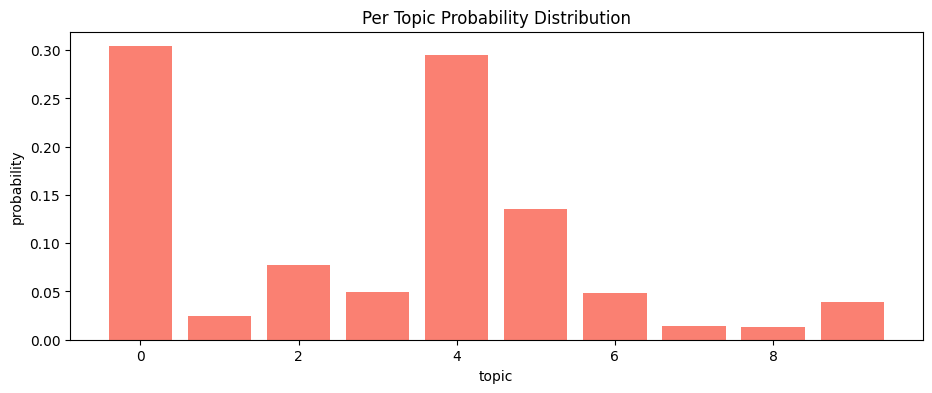

In [39]:
import matplotlib.pyplot as plt
%matplotlib inline

fig = plt.figure()
fig.set_size_inches(11,4)
plt.bar(topic_dist_table['Topic'], topic_dist_table['Probabilities'], align='center', alpha=1, color='salmon')
plt.xlabel('topic')
plt.ylabel('probability')
plt.title('Per Topic Probability Distribution')
plt.show()

### Include the topic proportions $\theta_d$ for each house


In [40]:
num_topics = 10
theta_matrix = tm.transform(dtm)
theta = pd.DataFrame(theta_matrix, columns=["Theta"+str(t) for t in range(num_topics)])

In [41]:
ct_topics = ct_homes.join(theta)
ct_topics

,AREA,BED,BATH,BUILT,DESCRIPTION,LOTSIZE,PRICE,logAREA,logLOTSIZE,logPRICE,Theta0,Theta1,Theta2,Theta3,Theta4,Theta5,Theta6,Theta7,Theta8,Theta9
0,1629.0,2.0,2.0,1889.0,"Welcome home! Charming & well kept, this 2 bed...",0.159986,224000.0,7.395722,-1.832669,12.319401,0.018291,0.023685,0.116536,0.239624,0.045531,0.036342,0.143212,0.040056,0.278703,0.058021
1,1278.0,3.0,2.0,1900.0,This adorable cape has a lot to offer. You st...,0.179981,225000.0,7.153052,-1.714902,12.323856,0.057786,0.096780,0.028674,0.194815,0.025343,0.023927,0.024421,0.443311,0.046980,0.057963
2,1264.0,3.0,2.0,1988.0,This 1264 sqft Colonial with its 3 bedrooms an...,0.089991,224900.0,7.142037,-2.408049,12.323411,0.042720,0.062149,0.187146,0.054292,0.016908,0.031368,0.265125,0.021980,0.301001,0.017312
3,2054.0,3.0,3.0,1960.0,The perfect oversized ranch awaits you at 7 No...,0.569994,370000.0,7.627544,-0.562129,12.821258,0.334054,0.055055,0.018597,0.274672,0.012260,0.108213,0.012356,0.066338,0.030520,0.087934
4,4198.0,5.0,3.0,1972.0,Beautiful Colonial-3020 sqft. living space and...,0.939989,489999.0,8.342364,-0.061887,13.102159,0.048904,0.203635,0.040924,0.404723,0.037771,0.092394,0.022819,0.052567,0.043127,0.053135
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1921,848.0,3.0,2.0,1948.0,This home sets at the beginning of a Cul-de-Sa...,0.189990,429900.0,6.742881,-1.660781,12.971308,0.099527,0.076471,0.034400,0.294028,0.022717,0.023772,0.027522,0.244935,0.139777,0.036851
1922,2400.0,4.0,4.0,2021.0,New home to be built. Amazing unobstructed wat...,0.079981,800000.0,7.783224,-2.525960,13.592367,0.274353,0.034274,0.030295,0.195961,0.031872,0.085944,0.224340,0.034542,0.044255,0.044165
1923,6538.0,7.0,7.0,2002.0,Can you say water views galore? Wake up to the...,0.079981,2700000.0,8.785387,-2.525960,14.808762,0.043069,0.251813,0.014894,0.014418,0.097486,0.265289,0.216183,0.040951,0.026791,0.029106
1924,4480.0,5.0,5.0,1890.0,NEW YEAR! NEW FUTURE! Escape NY to Connect...,0.849998,2550000.0,8.407378,-0.162521,14.751604,0.064909,0.103341,0.187916,0.025500,0.126809,0.032403,0.279803,0.018797,0.064625,0.095897


#### Fit a linear model with the topic proportions included

We now fit a linear model with the topic proportions included. Note that
the proportions satisfy $\theta_0+\theta_1+\cdots + \theta_9 = 1$. Therefore, we remove one of them, since it is redundant. If we don't do this the linear model will be harder to interpret!


In [42]:
model = sm.ols("logPRICE ~ logAREA + logLOTSIZE + BED + BATH + BUILT + Theta1 + " +
               "Theta2 + Theta3 + Theta4 + Theta5 + Theta6 + Theta7 + Theta8 + Theta9", data=ct_topics).fit()
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               logPRICE   R-squared:                       0.861
Model:                            OLS   Adj. R-squared:                  0.860
Method:                 Least Squares   F-statistic:                     844.0
Date:                Sat, 18 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:55:41   Log-Likelihood:                -959.78
No. Observations:                1926   AIC:                             1950.
Df Residuals:                    1911   BIC:                             2033.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.5393      0.503     11.002      0.000       4.552       6.527
logAREA        0.5375      0.032     16.794      0.000       0.475       0.600
logLOTSIZE     0.0253      0.009      2.878      0.004       0.008       0.043
BED           -0.0145      0.012     -1.192      0.233      -0.038       0.009
BATH           0.1201      0.010     12.043      0.000       0.101       0.140
BUILT          0.0016      0.000      7.246      0.000       0.001       0.002
Theta1        -0.9179      0.121     -7.612      0.000      -1.154      -0.681
Theta2        -0.3747      0.150     -2.498      0.013      -0.669      -0.081
Theta3        -0.1619      0.151     -1.069      0.285      -0.459       0.135
Theta4         2.1713      0.138     15.694      0.000       1.900       2.443
Theta5         0.1295      0.183      0.709      0.478      -0.229       0.488
Theta6         1.3133      0.138      9.508      0.000       1.042       1.584
Theta7        -0.5356      0.138     -3.889      0.000      -0.806      -0.266
Theta8        -0.5895      0.128     -4.590      0.000      -0.841      -0.338
Theta9        -0.7848      0.151     -5.197      0.000      -1.081      -0.489
==============================================================================
Omnibus:                      180.882   Durbin-Watson:                   1.603
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              693.544
Skew:                           0.399   Prob(JB):                    2.51e-151
Kurtosis:                       5.829   Cond. No.                     1.12e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.12e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

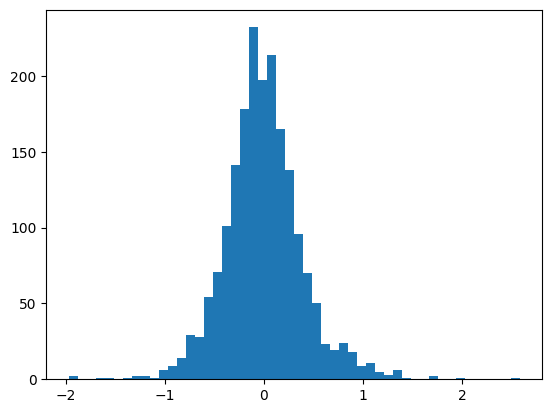

In [43]:
plt.hist(model.resid, bins=50)
plt.show()

### Model without the topics included


In [44]:
model_without_topics = sm.ols("logPRICE ~ logAREA + logLOTSIZE + BED + BATH + BUILT", data=ct_topics).fit()
model_without_topics.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               logPRICE   R-squared:                       0.787
Model:                            OLS   Adj. R-squared:                  0.786
Method:                 Least Squares   F-statistic:                     1417.
Date:                Sat, 18 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:55:54   Log-Likelihood:                -1370.4
No. Observations:                1926   AIC:                             2753.
Df Residuals:                    1920   BIC:                             2786.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.9172      0.528     11.203      0.000       4.881       6.953
logAREA        0.7285      0.035     20.723      0.000       0.660       0.797
logLOTSIZE     0.0673      0.010      6.481      0.000       0.047       0.088
BED           -0.0620      0.015     -4.214      0.000      -0.091      -0.033
BATH           0.2373      0.011     21.734      0.000       0.216       0.259
BUILT          0.0006      0.000      2.249      0.025    7.19e-05       0.001
==============================================================================
Omnibus:                      271.078   Durbin-Watson:                   1.530
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              863.510
Skew:                           0.705   Prob(JB):                    3.10e-188
Kurtosis:                       5.961   Cond. No.                     9.18e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.18e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Problem 1.2: Plot the residuals

On a single plot, show a histogram of the residuals of the model without the topics,
and the residuals of the model with the topics. Give a legend that shows which is which.
Comment on the results.


In [ ]:
# your code here

### Problem 1.3: Quantify the improvement: R-squared

How do the two models compare in terms of R-squared? What do these numbers mean?


**[Write your answer here]**

In [ ]:
# your code here

### Problem 1.5: Quantify the improvement: LOOCV

What is the percent decrease in the leave-one-out-cross-validation (LOOCV) error?
Recall from class that the following formula can be used to calculate this:

<img src="https://raw.githubusercontent.com/YData123/sds265-fa21/main/assignments/assn6/loocv.png" width="410" align="center">

<br>

The following line of code computes this for one of the models:

`np.mean((model.resid/(1 - model.get_influence().hat_matrix_diag))**2)`


In [ ]:
# your code here

### Problem 1.6: Repeat for three topics

Now, repeat the above steps for a topic model that is trained using only three (3) topics. Specifically:

1. Train a model with three topics
1. Display the top words in each of the three topics
1. Augment the `ct_homes` data with the resulting topic proportions $\theta$
1. Fit a linear model *using only the first two of the three* proportions
1. Plot a histogram of the residuals of the three linear models together
1. Comment on the improvement over the baseline in terms of R-squared, MSE, and LOOCV compared with the previous two models.


In [ ]:
# your code here

In [ ]:
ct_3topics

In [ ]:
model_3topics = sm.ols("logPRICE ~ logAREA + logLOTSIZE + BED + BATH + BUILT + Topic0 + Topic1", data=ct_3topics).fit()
model_3topics.summary()

### Problem 1.7: Interpretation

Return to the **10-topic model** from above and interpret the fitted regression. Use the coefficients of the linear model together with the top words in the topics to explain what the model is capturing. Comment on what this says about the effectiveness of the topic model for predicting the sale price of the house. Does it make intuitive sense? Why or why not?


**[Write your answer here]**

## Problem 2: Deep Neural Networks with PyTorch

In class, we discussed a "bare bones" implementation of a 2-layer neural network for classification using only `numpy`. In practice, we usually rely on libraries such as PyTorch, which handle automatic differentiation and make it much easier to build, train, and compare neural networks.

In this notebook, Problem 2 has two parts:

- **Problem 2.1:** spiral classification with feedforward neural networks
- **Problem 2.2:** generalization in modular addition


Recall that a 2-layer neural network for classification takes the following form,
\begin{aligned}
    h_{1} &=\operatorname{ReLU}\left(W_{1} X+b_{1}\right) \\
    p &=\operatorname{Softmax}\left(W_{2} h_{1}+b_{2}\right).
\end{aligned}
where $X$ is the input. The number of layers is referred to as the depth of a neural network. We can also construct deeper networks by stacking more hidden layers.

### Problem 2.1: Spiral Classification with Feedforward Neural Networks

In this part, we will train several feedforward neural networks with PyTorch on the spiral classification task. We will start with a simple baseline 2-layer model, then compare wider and deeper variants, and finally discuss how architecture affects both predictive performance and training dynamics.


In [ ]:
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

%matplotlib inline

SEED = 265
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams['figure.figsize'] = (10.0, 8.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

device = torch.device('cpu')
print('torch', torch.__version__)
print('device', device)


First we generate and plot a spiral dataset that contains $K=3$ classes.

In [ ]:
def generate_spirals(N=100, K=3, noise=0.3, seed=SEED):
    rng = np.random.default_rng(seed)
    X = np.zeros((N * K, 2), dtype=np.float32)
    y = np.zeros(N * K, dtype=np.int64)
    for j in range(K):
        ix = range(N * j, N * (j + 1))
        r = np.linspace(0.0, 1, N)
        t = np.linspace(j * 4, (j + 1) * 4, N) + rng.normal(scale=noise, size=N)
        X[ix] = np.c_[r * np.sin(t), r * np.cos(t)]
        y[ix] = j
    return X, y


def plot_data(X, y, title=None):
    plt.figure(figsize=(6, 6))
    plt.scatter(X[:, 0], X[:, 1], c=y, s=26, cmap=plt.cm.Spectral, edgecolors='none')
    plt.xlim(np.min(X[:, 0]) - 0.1, np.max(X[:, 0]) + 0.1)
    plt.ylim(np.min(X[:, 1]) - 0.1, np.max(X[:, 1]) + 0.1)
    plt.xlabel('x1')
    plt.ylabel('x2')
    if title:
        plt.title(title)
    plt.tight_layout()


def _decision_surface(ax, X_ref, model):
    h = 0.015
    x_min, x_max = X_ref[:, 0].min() - 0.2, X_ref[:, 0].max() + 0.2
    y_min, y_max = X_ref[:, 1].min() - 0.2, X_ref[:, 1].max() + 0.2
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    inputs = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
    with torch.no_grad():
        logits = model(torch.from_numpy(inputs).to(device))
        Z = logits.argmax(dim=1).cpu().numpy().reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.30)
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())


def plot_classifier_pair(X_train, y_train, X_test, y_test, model, base_title):
    X_ref = np.vstack([X_train, X_test])
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
    for ax, X, y, split, marker, size, alpha in [
        (axes[0], X_train, y_train, 'train', 'o', 24, 0.75),
        (axes[1], X_test, y_test, 'test', 'x', 34, 0.95),
    ]:
        _decision_surface(ax, X_ref, model)
        ax.scatter(
            X[:, 0], X[:, 1], c=y, s=size, cmap=plt.cm.Spectral,
            marker=marker, edgecolors='k' if marker == 'o' else None,
            linewidths=0.15 if marker == 'o' else 0.9, alpha=alpha
        )
        ax.set_xlabel('x1')
        ax.set_ylabel('x2')
        ax.set_title(f'{base_title}: {split}')
    plt.show()


def plot_history(history, title_prefix='', eval_label='validation'):
    epochs = np.arange(1, len(history['loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

    axes[0].plot(epochs, history['loss'], color='#1f77b4', linewidth=2.2, label='train')
    axes[0].plot(epochs, history['val_loss'], color='#ff7f0e', linewidth=2.2, label=eval_label)
    axes[0].fill_between(epochs, history['loss'], history['val_loss'], color='#d9d9d9', alpha=0.15)
    axes[0].set_title('Cross-Entropy Loss')
    axes[0].set_xlabel('epoch')
    axes[0].set_ylabel('loss')
    axes[0].grid(alpha=0.25)
    axes[0].legend(frameon=False)

    axes[1].plot(epochs, history['accuracy'], color='#2ca02c', linewidth=2.2, label='train')
    axes[1].plot(epochs, history['val_accuracy'], color='#d62728', linewidth=2.2, label=eval_label)
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('epoch')
    axes[1].set_ylabel('accuracy')
    axes[1].set_ylim(0.0, 1.02)
    axes[1].grid(alpha=0.25)
    axes[1].legend(frameon=False, loc='lower right')

    if title_prefix:
        fig.suptitle(title_prefix, fontsize=14, fontweight='bold')
    plt.show()


def make_model(input_dim, hidden_dims, output_dim):
    layers = []
    prev_dim = input_dim
    for hidden_dim in hidden_dims:
        layers.append(nn.Linear(prev_dim, hidden_dim))
        layers.append(nn.ReLU())
        prev_dim = hidden_dim
    layers.append(nn.Linear(prev_dim, output_dim))
    return nn.Sequential(*layers).to(device)


def summarize_model(model, label='model'):
    total_params = sum(p.numel() for p in model.parameters())
    print(label)
    print(model)
    print('parameters:', total_params)


def accuracy(model, X, y):
    model.eval()
    with torch.no_grad():
        logits = model(torch.from_numpy(X).to(device))
        preds = logits.argmax(dim=1).cpu().numpy()
    return float((preds == y).mean())


def train_neurnet(model, X, y, X_val, y_val, n_epochs=300, batch_size=128, lr=0.001):
    dataset = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    X_val_t = torch.from_numpy(X_val).to(device)
    y_val_t = torch.from_numpy(y_val).to(device)

    for _ in tqdm(range(n_epochs), leave=False):
        model.train()
        total_loss = 0.0
        total_correct = 0
        total_count = 0
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(xb)
            total_correct += (logits.argmax(dim=1) == yb).sum().item()
            total_count += len(xb)

        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_t)
            val_loss = criterion(val_logits, y_val_t).item()
            val_acc = (val_logits.argmax(dim=1) == y_val_t).float().mean().item()

        history['loss'].append(total_loss / total_count)
        history['accuracy'].append(total_correct / total_count)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)

    return history


def evaluate_model(name, model, X_train, y_train, X_val, y_val, X_test, y_test):
    train_acc = accuracy(model, X_train, y_train)
    val_acc = accuracy(model, X_val, y_val)
    test_acc = accuracy(model, X_test, y_test)
    print(f'{name}: train={train_acc:.3f} val={val_acc:.3f} test={test_acc:.3f}')
    return {'train_acc': train_acc, 'val_acc': val_acc, 'test_acc': test_acc}


In [ ]:
X_spiral, y_spiral = generate_spirals(N=300, K=3, seed=SEED)
X_spiral_val, y_spiral_val = generate_spirals(N=50, K=3, seed=SEED + 1)
X_spiral_test, y_spiral_test = generate_spirals(N=300, K=3, seed=SEED + 2)
plot_data(X_spiral, y_spiral, title='spiral train set')

#### Example: Baseline Two-Layer Network

We begin with a worked example on the spiral dataset. This baseline model uses:
- exactly **1 hidden layer**
- exactly **16 hidden units**
- **ReLU** activation
- output dimension fixed at **3 classes**

Use this example as a template for the student-written models below. In particular, pay attention to how the model is specified, how `train_neurnet(...)` is called, and how `plot_history(...)` and `plot_classifier_pair(...)` are used to inspect the result.


In [ ]:
neurnet = make_model(2, [16], 3)
summarize_model(neurnet, label='baseline relu')


In [ ]:
history = train_neurnet(neurnet, X_spiral, y_spiral, X_spiral_val, y_spiral_val, n_epochs=300, lr=0.01)
plot_history(history, title_prefix='baseline')
baseline_metrics = evaluate_model('baseline', neurnet, X_spiral, y_spiral, X_spiral_val, y_spiral_val, X_spiral_test, y_spiral_test)


In [ ]:
plot_classifier_pair(X_spiral, y_spiral, X_spiral_test, y_spiral_test, neurnet, 'baseline')

#### Problem 2.1.1: Wider Network

Using the same spiral setup, now train a wider neural network.

Use exactly:
- **1 hidden layer**
- **64 hidden units**
- **ReLU** activation
- output dimension fixed at **3 classes**

As before, specify the model, train it, inspect the training history, and visualize the decision boundary on the training and test sets. Then compare the result to the baseline model.


**Wider network**

Use exactly **1 hidden layer with 64 hidden units** and **ReLU** activation.


In [ ]:
# Specify the wider model here


In [ ]:
wider_history = train_neurnet(wider_model, X_spiral, y_spiral, X_spiral_val, y_spiral_val, n_epochs=250, lr=0.01)
plot_history(wider_history, title_prefix='wider 64')
wider_metrics = evaluate_model('wider', wider_model, X_spiral, y_spiral, X_spiral_val, y_spiral_val, X_spiral_test, y_spiral_test)


In [ ]:
plot_classifier_pair(X_spiral, y_spiral, X_spiral_test, y_spiral_test, wider_model, 'wider 64')


#### Problem 2.1.2: Deeper Network

Using the same spiral setup, now train a deeper neural network.

Use exactly:
- **4 hidden layers**
- **16 hidden units in each hidden layer**
- **ReLU** activation
- output dimension fixed at **3 classes**

As before, specify the model, train it, inspect the training history, and visualize the decision boundary on the training and test sets. Then compare the result to the baseline model.


In [ ]:
# Specify the deeper model here


In [ ]:
deeper_history = train_neurnet(deeper_model, X_spiral, y_spiral, X_spiral_val, y_spiral_val, n_epochs=250, lr=0.01)
plot_history(deeper_history, title_prefix='deeper 4-layer')
deeper_metrics = evaluate_model('deeper', deeper_model, X_spiral, y_spiral, X_spiral_val, y_spiral_val, X_spiral_test, y_spiral_test)


In [ ]:
plot_classifier_pair(X_spiral, y_spiral, X_spiral_test, y_spiral_test, deeper_model, 'deeper 4-layer')

#### Problem 2.1.3: Compare Model Performance and Training Dynamics


When comparing neural networks, it is useful to look at more than just the final test accuracy.

In particular, you should pay attention to:
- **Accuracy:** how often the model predicts the correct class
- **Loss:** the cross-entropy objective that the optimizer is actually minimizing
- **Training dynamics:** whether the loss curves are smooth and well-behaved, or whether they show large oscillations and spikes

Create a table comparing the three models you have trained:
- baseline ReLU with **16** hidden units
- wider ReLU with **64** hidden units
- deeper ReLU with **4 hidden layers of width 16**

Your table should include both **accuracy** and **loss** information, and you should use the plotted learning curves to comment on the optimization behavior of each model.


In [ ]:
# Build a comparison table for baseline, wider, and deeper here.
# Include both loss and accuracy.
# Hint:
# comparison = pd.DataFrame([
#     {
#         'model': 'baseline relu',
#         'final_train_loss': history['loss'][-1],
#         'final_val_loss': history['val_loss'][-1],
#         'train_accuracy': baseline_metrics['train_acc'],
#         'val_accuracy': baseline_metrics['val_acc'],
#         'test_accuracy': baseline_metrics['test_acc'],
#     },
# ])


Comment on your findings.

In particular, answer the following questions.

1. By widening and deepening the model, how does the performance change?
2. Compare the loss curves of the wider and deeper models with the baseline model. How do they look?


**[Write your answer here]**

In modular addition, each example is a pair $(a, b)$ and the label is
$$
y = (a + b) \bmod p.
$$

We will only train on part of the full input-output table, and then test on unseen pairs. This gives us a clean setting for comparing:
- **performance**, measured by both cross-entropy loss and accuracy
- **generalization**, meaning how well the model does on unseen examples

In this part, weight decay is important. For a model with parameters $\theta$, weight decay adds an L2 penalty to the objective:
$$
\mathcal{L}_{\text{total}}(\theta) = \mathcal{L}_{\text{CE}}(\theta) + \lambda \lVert \theta \rVert_2^2.
$$
Here $\mathcal{L}_{\text{CE}}$ is the usual cross-entropy loss, and the extra L2 term discourages the optimizer from using unnecessarily large weights. We will compare training with and without this regularization.


#### Setup

We will use the prime modulus $p = 17$. The full dataset contains all $17^2 = 289$ ordered pairs $(a, b)$, but we will train on only 85% of them. To keep the modeling part simple, the data is already formatted for you:
- each input is a concatenation of two one-hot vectors, so the input dimension is `2 * p`
- each label is an integer in `{0, 1, ..., p - 1}`
- the train/test split is created for you

You will train the same **two-layer neural network** in two regimes:
1. without weight decay
2. with weight decay

We also reset the random seed before the modular-addition model is built so that this experiment is reproducible.


In [ ]:
def make_modular_addition_data(p=19):
    X = []
    y = []

    for a in range(p):
        for b in range(p):
            features = torch.zeros(2 * p, dtype=torch.float32)
            features[a] = 1.0
            features[p + b] = 1.0
            X.append(features)
            y.append((a + b) % p)

    X = torch.stack(X)
    y = torch.tensor(y, dtype=torch.long)
    return X, y


def modular_train_test_split(X, y, train_frac=0.75, seed=SEED):
    generator = torch.Generator().manual_seed(seed)
    perm = torch.randperm(len(y), generator=generator)
    n_train = int(train_frac * len(y))
    train_idx = perm[:n_train]
    test_idx = perm[n_train:]
    return X[train_idx], y[train_idx], X[test_idx], y[test_idx]


def evaluate_tensor_model(model, X, y, loss_fn):
    model.eval()
    with torch.no_grad():
        logits = model(X.to(device))
        loss = loss_fn(logits, y.to(device)).item()
        acc = (logits.argmax(dim=1) == y.to(device)).float().mean().item()
    return loss, acc


def train_neurnet_full_batch(model, X_train, y_train, X_test, y_test, n_epochs=5000, lr=1e-3, weight_decay=0.0):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.CrossEntropyLoss()
    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

    X_train = X_train.to(device)
    y_train = y_train.to(device)
    X_test = X_test.to(device)
    y_test = y_test.to(device)

    for _ in tqdm(range(n_epochs), leave=False):
        train_loss, train_acc = evaluate_tensor_model(model, X_train, y_train, loss_fn)
        test_loss, test_acc = evaluate_tensor_model(model, X_test, y_test, loss_fn)

        history['loss'].append(train_loss)
        history['accuracy'].append(train_acc)
        history['val_loss'].append(test_loss)
        history['val_accuracy'].append(test_acc)

        model.train()
        optimizer.zero_grad()
        logits = model(X_train)
        loss = loss_fn(logits, y_train)
        loss.backward()
        optimizer.step()

    return history


First, generate the modular-addition dataset and create the train/test split.


In [ ]:
P_MOD = 17
TRAIN_FRAC_MOD = 0.85

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

X_mod, y_mod = make_modular_addition_data(p=P_MOD)
X_mod_train, y_mod_train, X_mod_test, y_mod_test = modular_train_test_split(
    X_mod, y_mod, train_frac=TRAIN_FRAC_MOD, seed=SEED
)

print('X_mod shape:', tuple(X_mod.shape))
print('y_mod shape:', tuple(y_mod.shape))
print('X_mod_train shape:', tuple(X_mod_train.shape))
print('X_mod_test shape:', tuple(X_mod_test.shape))
print('number of classes:', len(torch.unique(y_mod)))


#### Problem 2.2.1: Train Without Weight Decay

Train a modular-addition network with the following model and optimization setup:
- network: a **two-layer neural network** with input dimension `2 * P_MOD`, one hidden layer of width `128`, `ReLU` activation, and output dimension `P_MOD`
- optimizer: `AdamW`
- learning rate: `1e-2`
- weight decay: `0.0`
- number of epochs: `5000`

Then plot the train/test loss and train/test accuracy curves. A good starting point is to call `plot_history(...)` after training.


In [ ]:
# Train the modular-addition model without weight decay here.
# Suggested pattern:
# modular_no_decay_model = ...
# modular_no_decay_history = ...
# plot_history(...)


#### Problem 2.2.2: Train With Weight Decay

Train the same modular-addition architecture again, but now use weight decay.

Use the following model and optimization setup:
- network: a **two-layer neural network** with input dimension `2 * P_MOD`, one hidden layer of width `128`, `ReLU` activation, and output dimension `P_MOD`
- optimizer: `AdamW`
- learning rate: `1e-2`
- weight decay: `1.0`
- number of epochs: `5000`

Plot the train/test loss and train/test accuracy curves again. As before, use `plot_history(...)` to inspect the result.


In [ ]:
# Train the same modular-addition model with weight decay here.
# Suggested pattern:
# modular_decay_model = ...
# modular_decay_history = ...
# plot_history(...)


#### Problem 2.2.3: Compare the Two Runs

Use the learning curves above to answer the following questions.

1. How do the train and test loss curves differ across the two runs?
2. Based on these plots, what role does weight decay seem to play in generalization for this task?

Hint:
Look carefully at both the loss curves and the accuracy curves, and compare how the training behavior and test behavior evolve over time.


**[Write your answer here]**

## Problem 3: Reinforcement Learning with Frozen Lake

In this problem, you will use **Q-learning** to train an agent to solve the Frozen Lake environment. The goal is to understand how reinforcement learning differs from supervised learning, how value-based learning works, and how the difficulty of the environment changes when transitions become random.


### Background

In Frozen Lake, the agent starts at `S` and aims to reach the goal `G` without falling into any holes `H`. The state is the agent's current position on the grid, and the available actions are moving up, down, left, or right. The reward is sparse: the agent receives a reward of `1` only when it reaches the goal, and `0` otherwise. This makes Frozen Lake a useful example for reinforcement learning, since the agent must learn from delayed feedback rather than from labeled training examples.

A typical 4x4 map looks like this:

```text
S F F F
F H F H
F F F H
H F F G
```

Here:
- `S` is the starting state
- `F` is a safe frozen tile
- `H` is a hole
- `G` is the goal


### Q-Learning Review

Q-learning learns a **Q-function** $Q(s, a)$, which estimates the long-run value of taking action $a$ in state $s$ and then acting optimally afterward. The update rule is

$$
Q(s,a) \leftarrow Q(s,a) + \alpha \Bigl[r + \gamma \max_{a'} Q(s',a') - Q(s,a)\Bigr],
$$

where:
- $s$ is the current state
- $a$ is the chosen action
- $r$ is the reward received after taking the action
- $s'$ is the next state
- $\alpha$ is the learning rate
- $\gamma$ is the discount factor

In words, the current estimate $Q(s, a)$ is nudged toward a better target: the immediate reward plus the best estimated future value available from the next state. In Frozen Lake, useful information has to propagate backward from the rare successful episodes where the agent actually reaches the goal.


We will study two versions of the environment:
- the deterministic environment, where actions move exactly as intended
- the slippery environment, where transitions are random and learning is harder

The key difference is that in the deterministic version, choosing an action like `right` always moves the agent right. In the slippery version, the same intended action may send the agent in a different direction. So in the slippery case, the agent must learn under transition uncertainty rather than assuming perfect control.


In [ ]:
import gymnasium as gym
import numpy as np
import random
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

%matplotlib inline

SEED = 265
random.seed(SEED)
np.random.seed(SEED)


First, load a few helper functions for resetting the environment, stepping through the environment, visualizing the map and the learned value function, and evaluating a learned Q-table.


In [ ]:
def reset_env(env, seed=None):
    out = env.reset(seed=seed)
    return out[0] if isinstance(out, tuple) else out


def step_env(env, action):
    out = env.step(action)
    if len(out) == 5:
        next_state, reward, terminated, truncated, info = out
        done = terminated or truncated
        return next_state, reward, done, info
    next_state, reward, done, info = out
    return next_state, reward, done, info


def get_frozen_lake_map(env):
    desc = env.unwrapped.desc
    return np.array([[cell.decode('utf-8') for cell in row] for row in desc])


def plot_frozen_lake_map(env, title='Frozen Lake Map'):
    tile_map = get_frozen_lake_map(env)
    color_lookup = {'S': 0, 'F': 1, 'H': 2, 'G': 3}
    colors = np.vectorize(color_lookup.get)(tile_map)
    cmap = plt.matplotlib.colors.ListedColormap(['#8ecae6', '#edf6f9', '#6d6875', '#90be6d'])

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(colors, cmap=cmap, vmin=0, vmax=3)

    for r in range(tile_map.shape[0]):
        for c in range(tile_map.shape[1]):
            ax.text(c, r, tile_map[r, c], ha='center', va='center', fontsize=18, fontweight='bold')

    ax.set_xticks(np.arange(-0.5, tile_map.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, tile_map.shape[0], 1), minor=True)
    ax.grid(which='minor', color='white', linewidth=2)
    ax.tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)
    ax.set_title(title, fontsize=14, fontweight='bold')
    plt.show()


def display_value_function(env, q_table, title='Learned Value Function'):
    tile_map = get_frozen_lake_map(env)
    values = np.max(q_table, axis=1).reshape(tile_map.shape)
    policy = np.argmax(q_table, axis=1).reshape(tile_map.shape)
    arrows = {0: '←', 1: '↓', 2: '→', 3: '↑'}

    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(values, cmap='YlGnBu', vmin=0, vmax=max(1e-8, values.max()))

    for r in range(tile_map.shape[0]):
        for c in range(tile_map.shape[1]):
            tile = tile_map[r, c]
            value_text = f'{values[r, c]:.2f}'
            if tile in {'H', 'G'}:
                ax.text(c, r - 0.14, tile, ha='center', va='center', fontsize=16, fontweight='bold', color='black')
                ax.text(c, r + 0.18, value_text, ha='center', va='center', fontsize=11, color='black')
            else:
                ax.text(c, r - 0.18, tile, ha='center', va='center', fontsize=14, fontweight='bold', color='black')
                ax.text(c, r + 0.02, arrows[int(policy[r, c])], ha='center', va='center', fontsize=20, color='black')
                ax.text(c, r + 0.28, value_text, ha='center', va='center', fontsize=10, color='black')

    ax.set_xticks(np.arange(-0.5, tile_map.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, tile_map.shape[0], 1), minor=True)
    ax.grid(which='minor', color='white', linewidth=2)
    ax.tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)
    ax.set_title(title, fontsize=15, fontweight='bold')
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('max_a Q(s, a)', rotation=90)
    plt.show()


def evaluate_Q_function(env, q_table, epsilon=.001, episodes=1000, seed=SEED):
    total_steps, total_successes = 0, 0

    for ep in range(episodes):
        state = reset_env(env, seed=seed + 10_000 + ep)
        done = False
        steps = 0
        reward = 0

        while not done:
            if random.uniform(0, 1) < epsilon:
                action = random.randrange(env.action_space.n)
            else:
                action = int(np.argmax(q_table[state]))

            next_state, reward, done, _ = step_env(env, action)
            state = next_state
            steps += 1

        total_steps += steps
        total_successes += reward

    print(f'Results after {episodes} episodes:')
    print(f'Average steps per episode: {total_steps / episodes:.3f}')
    print(f'Chance of success: {total_successes / episodes:.3f}')

    return {
        'avg_steps': total_steps / episodes,
        'success_rate': total_successes / episodes,
    }


### Problem 3.1: Complete the Q-Learning Update

In the cell below, complete the core Q-learning update. This is the main implementation task.

Your function should:
- initialize the Q-table
- use epsilon-greedy exploration
- update the Q-table after each transition
- correctly handle terminal states

The student-filled part is the short block immediately after
`next_state, reward, done, _ = step_env(env, action)`.


In [ ]:
def Q_learning(env, alpha=.1, gamma=.95, epsilon=.1, episodes=10000, seed=SEED):
    # Initialize the Q-table with one row per state and one column per action.
    q_table = 0.5 * np.ones([env.observation_space.n, env.action_space.n])

    # Set the random seeds for reproducibility.
    random.seed(seed)
    np.random.seed(seed)

    # Loop over training episodes.
    for ep in tqdm(range(episodes)):
        # Reset the environment to get the starting state.
        state = reset_env(env, seed=seed + ep)
        done = False

        # Continue until the episode ends.
        while not done:
            # With probability epsilon, explore by choosing a random action.
            if random.uniform(0, 1) < epsilon:
                action = env.action_space.sample()
            else:
                # Otherwise exploit by choosing the action with largest Q-value.
                action = int(np.argmax(q_table[state]))

            # Take one step in the environment.
            next_state, reward, done, _ = step_env(env, action)

            # If the episode ended, set the Q-values of the terminal state to zero.
            # [your code here] #Read the old Q-value at (state, action).
            # [your code here] #Compute next_max = max_a' Q(next_state, a').
            # [your code here] #Apply the Q-learning update.

            # Move to the next state.
            state = next_state

    return q_table


### Problem 3.2: Deterministic Frozen Lake Example

We begin with a worked example on the deterministic environment (`is_slippery=False`). Use this as a template for the slippery case below.


In [ ]:
env_det = gym.make('FrozenLake-v1', is_slippery=False)
plot_frozen_lake_map(env_det, title='Deterministic Frozen Lake Map')
q_det = Q_learning(env_det, alpha=.1, gamma=.95, epsilon=.1, episodes=50000)
display_value_function(env_det, q_det, title='Deterministic Frozen Lake: value and greedy policy')
det_metrics = evaluate_Q_function(env_det, q_det, episodes=5000)


### Problem 3.3: Slippery Frozen Lake

Now apply your Q-learning implementation to the slippery environment.

Use the provided environment setup below, then:
- train Q-learning
- display the learned value function and greedy policy
- evaluate the learned Q-function


In [ ]:
env_slip = gym.make('FrozenLake-v1', is_slippery=True)
# Train your Q-learning agent on the slippery environment here.
# Then visualize the learned value function and evaluate the learned policy.


### Problem 3.4: Compare the Two Results

Compare the deterministic and slippery environments. Which one is more challenging, and how do the results show that?


**[Write your answer here]**
